# Week 4 — TCDD Train Delay Prediction Pipeline

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 48 sütunlu tabloda pandas'ın sütunları "..." ile kırpmasını engelle
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

sns.set_theme(style="whitegrid")

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 1. Schema Audit & Relational Joining

In [2]:
DATA_DIR = "tcdd_data/"

seferler = pd.read_csv(DATA_DIR + "seferler_log.csv")
bakim    = pd.read_csv(DATA_DIR + "tren_bakim_gecmisi.csv")
hatlar   = pd.read_csv(DATA_DIR + "hat_bilgileri.csv")

for name, df in [("seferler_log", seferler),
                 ("tren_bakim_gecmisi", bakim),
                 ("hat_bilgileri", hatlar)]:
    print(f"{name:22s} → {df.shape[0]:>6,} satır × {df.shape[1]:>2} sütun")

print(f"\nToplam sütun: {seferler.shape[1] + bakim.shape[1] + hatlar.shape[1]}")

seferler_log           → 12,000 satır × 21 sütun
tren_bakim_gecmisi     →    250 satır × 14 sütun
hat_bilgileri          →     40 satır × 13 sütun

Toplam sütun: 48


In [3]:
seferler.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   sefer_id                       12000 non-null  object 
 1   tren_id                        12000 non-null  object 
 2   hat_id                         12000 non-null  object 
 3   planlanan_kalkis               12000 non-null  object 
 4   planlanan_varis                12000 non-null  object 
 5   fiili_kalkis_gecikmesi_dk      12000 non-null  float64
 6   yolcu_sayisi                   11332 non-null  float64
 7   biletli_doluluk_orani_pct      12000 non-null  float64
 8   bagaj_vagonu_yuk_kg            12000 non-null  int64  
 9   makinist_vardiya_saati         12000 non-null  int64  
 10  makinist_deneyim_yili          12000 non-null  int64  
 11  hava_durumu                    10467 non-null  object 
 12  ortam_sicakligi_c              12000 non-null 

In [4]:
seferler.head()

,sefer_id,tren_id,hat_id,planlanan_kalkis,planlanan_varis,fiili_kalkis_gecikmesi_dk,yolcu_sayisi,biletli_doluluk_orani_pct,bagaj_vagonu_yuk_kg,makinist_vardiya_saati,makinist_deneyim_yili,hava_durumu,ortam_sicakligi_c,ruzgar_hizi_kmh,bilet_kontrol_cihaz_versiyonu,makinist_sicil_no,yardimci_makinist_sicil_no,yemek_servisi_var_mi,vagon_klima_arizasi_bildirimi,temizlik_firmasi_kodu,gecikme_suresi_dk
0,SEFER-00001,TREN-349,HAT-10,2026-05-02 00:15:00,2026-05-02 02:15:00,9.1,421.0,62.1,795,10,4,Karli,21.9,29.6,v2.1.0,M-4879,YM-5778,1,1,TemizYol Ltd,34.4
1,SEFER-00002,TREN-280,HAT-21,06.08.2025 08:30,06.08.2025 13:30,0.9,638.0,37.6,965,3,15,NaN,5.7,9.1,v3.0.0,M-6051,YM-8591,1,0,CLN-Express,16.3
2,SEFER-00003,TREN-141,HAT-20,2026-07-19 08:45:00,2026-07-19 09:45:00,1.6,294.0,97.8,3346,9,2,Firtinali,3.0,74.3,v3.0.0,M-5093,YM-2551,1,0,CleanRail A.S.,33.5
3,SEFER-00004,TREN-132,HAT-01,2025-02-12 07:10:00,2025-02-12 10:10:00,1.9,126.0,70.8,2220,2,1,Yagmurlu,-0.1,48.4,v2.4.1,M-3007,YM-1699,1,0,CleanRail A.S.,34.8
4,SEFER-00005,TREN-337,HAT-37,2025-10-23 21:30:00,2025-10-24 05:30:00,2.2,231.0,49.2,3753,3,2,Sisli,22.4,37.4,v1.0.4,M-5583,YM-7275,0,1,CleanRail A.S.,38.9


In [5]:
bakim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tren_id                     250 non-null    object 
 1   tren_tipi                   250 non-null    object 
 2   uretim_yili                 250 non-null    int64  
 3   lokomotif_yasi              250 non-null    int64  
 4   toplam_kilometre_km         250 non-null    int64  
 5   son_servis_gun_sayisi       250 non-null    int64  
 6   motor_saglik_skoru          219 non-null    float64
 7   fren_balata_asinma_pct      250 non-null    float64
 8   tekerlek_profil_asinma_mm   250 non-null    float64
 9   depo_sorumlusu_adi          250 non-null    object 
 10  depo_kodu                   250 non-null    object 
 11  garanti_durumu              250 non-null    object 
 12  son_bakim_maliyeti_tl       250 non-null    int64  
 13  yedek_parca_tedarikci_kodu  250 non

In [6]:
bakim.head()

,tren_id,tren_tipi,uretim_yili,lokomotif_yasi,toplam_kilometre_km,son_servis_gun_sayisi,motor_saglik_skoru,fren_balata_asinma_pct,tekerlek_profil_asinma_mm,depo_sorumlusu_adi,depo_kodu,garanti_durumu,son_bakim_maliyeti_tl,yedek_parca_tedarikci_kodu
0,TREN-101,YHT,2015,11,1253556,127,86.5,67.5,10.8,Ahmet Yilmaz,DEP-ANK,Devam Ediyor,65580,SUP-7912
1,TREN-102,Bolgesel,2002,24,2219613,15,85.4,69.6,5.3,Zeynep Ozturk,DEP-ANK,Devam Ediyor,255514,SUP-5557
2,TREN-103,Yuk,2005,21,1265476,81,87.8,18.7,4.9,Mustafa Celik,DEP-IZM,Devam Ediyor,208208,SUP-6635
3,TREN-104,Yuk,2012,14,623558,195,NaN,34.9,7.7,Mustafa Celik,DEP-IST,Uzatildi,484231,SUP-6925
4,TREN-105,YHT,2015,11,1055874,150,92.3,83.7,4.9,Mehmet Demir,DEP-IZM,Bitti,257717,SUP-6977


In [7]:
hatlar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   hat_id                     40 non-null     object 
 1   kalkis_istasyonu           40 non-null     object 
 2   varis_istasyonu            40 non-null     object 
 3   mesafe_km                  40 non-null     int64  
 4   hat_tipi                   40 non-null     object 
 5   maksimum_hiz_kmh           40 non-null     int64  
 6   zorluk_indeksi             40 non-null     float64
 7   viraj_sayisi               40 non-null     int64  
 8   hemzemin_gecit_sayisi      40 non-null     int64  
 9   bolge_mudurlugu            40 non-null     object 
 10  hat_insaat_yili            40 non-null     int64  
 11  istasyon_muduru_telefon    40 non-null     object 
 12  peron_yenileme_butcesi_tl  40 non-null     int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 4.2

In [8]:
hatlar.head()

,hat_id,kalkis_istasyonu,varis_istasyonu,mesafe_km,hat_tipi,maksimum_hiz_kmh,zorluk_indeksi,viraj_sayisi,hemzemin_gecit_sayisi,bolge_mudurlugu,hat_insaat_yili,istasyon_muduru_telefon,peron_yenileme_butcesi_tl
0,HAT-01,Ankara Gar,Istanbul Sogutlucesme,533,Yüksek Hizli,250,1.0,15,2,3. Bolge (Izmir),2019,0555-310-9482,2745635
1,HAT-02,ANKARA,Eskisehir,245,Yüksek Hizli,250,0.8,10,0,2. Bolge (Ankara),2000,0555-865-7418,1439593
2,HAT-03,ank-gar,Konya,312,Yüksek Hizli,250,0.9,8,1,1. Bolge (Istanbul),2017,0555-902-4921,2275709
3,HAT-04,Istanbul Pendik,Eskisehir Gar,288,Elektrikli-Sinyalli,200,1.1,18,5,1. Bolge (Istanbul),1984,0555-346-9185,2876311
4,HAT-05,Izmir Alsancak,Aydin,130,Tek Hat,120,1.5,45,22,1. Bolge (Istanbul),2011,0555-640-1197,1714555


In [9]:
def sutun_envanteri(df, tablo_adi):
    """Her sütun için tip, eksik oranı, benzersiz değer sayısı ve örnek değer."""
    rapor = pd.DataFrame({
        "tip": df.dtypes.astype(str),
        "eksik": df.isna().sum(),
        "eksik_%": (df.isna().mean() * 100).round(1),
        "benzersiz": df.nunique(),
        "ornek": [df[c].dropna().iloc[0] if df[c].notna().any() else None
                  for c in df.columns],
    })
    rapor.index.name = f"{tablo_adi} ({df.shape[0]}×{df.shape[1]})"
    return rapor

sutun_envanteri(seferler, "seferler_log")

,tip,eksik,eksik_%,benzersiz,ornek
seferler_log (12000×21),,,,,
sefer_id,object,0,0.0,12000,SEFER-00001
tren_id,object,0,0.0,250,TREN-349
hat_id,object,0,0.0,40,HAT-10
planlanan_kalkis,object,0,0.0,11222,2026-05-02 00:15:00
planlanan_varis,object,0,0.0,11309,2026-05-02 02:15:00
fiili_kalkis_gecikmesi_dk,float64,0,0.0,251,9.1
yolcu_sayisi,float64,668,5.6,651,421.0
biletli_doluluk_orani_pct,float64,0,0.0,701,62.1
bagaj_vagonu_yuk_kg,int64,0,0.0,4111,795


In [10]:
sutun_envanteri(bakim, "tren_bakim_gecmisi")

,tip,eksik,eksik_%,benzersiz,ornek
tren_bakim_gecmisi (250×14),,,,,
tren_id,object,0,0.0,250,TREN-101
tren_tipi,object,0,0.0,5,YHT
uretim_yili,int64,0,0.0,30,2015
lokomotif_yasi,int64,0,0.0,30,11
toplam_kilometre_km,int64,0,0.0,250,1253556
son_servis_gun_sayisi,int64,0,0.0,182,127
motor_saglik_skoru,float64,31,12.4,188,86.5
fren_balata_asinma_pct,float64,0,0.0,214,67.5
tekerlek_profil_asinma_mm,float64,0,0.0,102,10.8


In [11]:
sutun_envanteri(hatlar, "hat_bilgileri")

,tip,eksik,eksik_%,benzersiz,ornek
hat_bilgileri (40×13),,,,,
hat_id,object,0,0.0,40,HAT-01
kalkis_istasyonu,object,0,0.0,40,Ankara Gar
varis_istasyonu,object,0,0.0,20,Istanbul Sogutlucesme
mesafe_km,int64,0,0.0,39,533
hat_tipi,object,0,0.0,4,Yüksek Hizli
maksimum_hiz_kmh,int64,0,0.0,8,250
zorluk_indeksi,float64,0,0.0,15,1.0
viraj_sayisi,int64,0,0.0,20,15
hemzemin_gecit_sayisi,int64,0,0.0,17,2


In [12]:
s_cols, b_cols, h_cols = set(seferler.columns), set(bakim.columns), set(hatlar.columns)

print("seferler ∩ bakim :", s_cols & b_cols)
print("seferler ∩ hatlar:", s_cols & h_cols)
print("bakim    ∩ hatlar:", b_cols & h_cols)

seferler ∩ bakim : {'tren_id'}
seferler ∩ hatlar: {'hat_id'}
bakim    ∩ hatlar: set()


In [13]:
print("seferler'deki benzersiz tren_id :", seferler["tren_id"].nunique())
print("bakim'daki benzersiz tren_id    :", bakim["tren_id"].nunique())
print("bakim'da karşılığı OLMAYAN      :", (~seferler["tren_id"].isin(bakim["tren_id"])).sum())
print()
print("seferler'deki benzersiz hat_id  :", seferler["hat_id"].nunique())
print("hatlar'daki benzersiz hat_id    :", hatlar["hat_id"].nunique())
print("hatlar'da karşılığı OLMAYAN     :", (~seferler["hat_id"].isin(hatlar["hat_id"])).sum())
print()
print("bakim'da tren_id duplike var mı :", bakim["tren_id"].duplicated().any())
print("hatlar'da hat_id duplike var mı :", hatlar["hat_id"].duplicated().any())

seferler'deki benzersiz tren_id : 250
bakim'daki benzersiz tren_id    : 250
bakim'da karşılığı OLMAYAN      : 0

seferler'deki benzersiz hat_id  : 40
hatlar'daki benzersiz hat_id    : 40
hatlar'da karşılığı OLMAYAN     : 0

bakim'da tren_id duplike var mı : False
hatlar'da hat_id duplike var mı : False


In [14]:
# 3 tabloyu tek master DataFrame'de birleştir
df = (seferler
      .merge(bakim,  on="tren_id", how="left")
      .merge(hatlar, on="hat_id",  how="left"))

print("Merge sonrası :", df.shape)
print("Beklenen satır: 12000")
print("Beklenen sütun: 21 + 14 + 13 - 2 (tekrar eden anahtarlar) = 46")
print()
print("Merge sonrası oluşan NaN'lar (join'den kaynaklı olanlar):")
merge_sonrasi = df[bakim.columns.drop("tren_id").tolist() +
                   hatlar.columns.drop("hat_id").tolist()].isna().sum()
print(merge_sonrasi[merge_sonrasi > 0] if (merge_sonrasi > 0).any()
      else "  Yok — sadece kaynak tablodaki mevcut eksikler taşındı.")

Merge sonrası : (12000, 46)
Beklenen satır: 12000
Beklenen sütun: 21 + 14 + 13 - 2 (tekrar eden anahtarlar) = 46

Merge sonrası oluşan NaN'lar (join'den kaynaklı olanlar):
motor_saglik_skoru    1509
dtype: int64


In [15]:
# Tartışmalı sayısal sütunların hedefle korelasyonu
tartismali_sayisal = [
    "makinist_vardiya_saati",
    "yemek_servisi_var_mi",
    "vagon_klima_arizasi_bildirimi",
    "uretim_yili",
    "lokomotif_yasi",
    "hat_insaat_yili",
]

kor = df[tartismali_sayisal + ["gecikme_suresi_dk"]].corr()["gecikme_suresi_dk"]
print("Hedefle korelasyon:")
print(kor.drop("gecikme_suresi_dk").sort_values(key=abs, ascending=False).round(3))

print("\nuretim_yili ↔ lokomotif_yasi korelasyonu:",
      round(df["uretim_yili"].corr(df["lokomotif_yasi"]), 3))

Hedefle korelasyon:
hat_insaat_yili                  0.016
vagon_klima_arizasi_bildirimi   -0.008
yemek_servisi_var_mi             0.004
makinist_vardiya_saati          -0.003
lokomotif_yasi                  -0.001
uretim_yili                      0.001
Name: gecikme_suresi_dk, dtype: float64

uretim_yili ↔ lokomotif_yasi korelasyonu: -1.0


In [16]:
# Tartışmalı kategoriklerin gruplara göre ortalama gecikmesi
for sutun in ["depo_kodu", "garanti_durumu", "bolge_mudurlugu", "tren_tipi", "hat_tipi"]:
    ozet = df.groupby(sutun)["gecikme_suresi_dk"].agg(["mean", "count"]).round(1)
    print(f"\n--- {sutun} ---")
    print(ozet.sort_values("mean", ascending=False))


--- depo_kodu ---
           mean  count
depo_kodu             
DEP-KNY    17.8   1821
DEP-ADA    13.9   2082
DEP-SVS    13.8   2019
DEP-ANK    13.3   2017
DEP-IST    11.9   1851
DEP-IZM    11.3   2210

--- garanti_durumu ---
                mean  count
garanti_durumu             
Devam Ediyor    15.0   3785
Bitti           13.0   4300
Uzatildi        12.9   3915

--- bolge_mudurlugu ---
                     mean  count
bolge_mudurlugu                 
6. Bolge (Adana)     17.2   2401
1. Bolge (Istanbul)  14.2   1825
4. Bolge (Sivas)     14.1    611
2. Bolge (Ankara)    13.2   2373
3. Bolge (Izmir)     12.5   2729
5. Bolge (Malatya)   10.6   2061

--- tren_tipi ---
           mean  count
tren_tipi             
YHT        16.3   2536
Banliyo    13.3   2178
Anahat     13.1   2364
Yuk        12.8   2843
Bolgesel   12.3   2079

--- hat_tipi ---
                     mean  count
hat_tipi                        
Cift Hat             16.3   1757
Tek Hat              14.3   6688
Yüksek Hizli  

In [17]:
# bolge_mudurlugu gerçekten bağımsız sinyal mi, yoksa hat_tipi'nin kopyası mı?
print(pd.crosstab(df["bolge_mudurlugu"], df["hat_tipi"]))
print("\n--- hat_tipi sabit tutulunca bölge farkı kalıyor mu? ---")
print(df.groupby(["hat_tipi", "bolge_mudurlugu"])["gecikme_suresi_dk"]
        .agg(["mean", "count"]).round(1))

hat_tipi             Cift Hat  Elektrikli-Sinyalli  Tek Hat  Yüksek Hizli
bolge_mudurlugu                                                          
1. Bolge (Istanbul)         0                  292     1231           302
2. Bolge (Ankara)         282                    0     1454           637
3. Bolge (Izmir)          588                  292     1273           576
4. Bolge (Sivas)            0                    0      611             0
5. Bolge (Malatya)          0                  593      896           572
6. Bolge (Adana)          887                    0     1223           291

--- hat_tipi sabit tutulunca bölge farkı kalıyor mu? ---
                                         mean  count
hat_tipi            bolge_mudurlugu                 
Cift Hat            2. Bolge (Ankara)    19.3    282
                    3. Bolge (Izmir)     14.6    588
                    6. Bolge (Adana)     16.5    887
Elektrikli-Sinyalli 1. Bolge (Istanbul)  15.7    292
                    3. Bolge (Iz

In [18]:
print(df["gecikme_suresi_dk"].describe().round(1))
print("\nStandart sapma:", round(df["gecikme_suresi_dk"].std(), 1), "dk")

count    12000.0
mean        13.6
std        113.5
min       -999.0
25%         15.7
50%         25.5
75%         34.6
max         98.6
Name: gecikme_suresi_dk, dtype: float64

Standart sapma: 113.5 dk


In [19]:
hedef = df["gecikme_suresi_dk"]

print("-999 sayısı        :", (hedef == -999).sum())
print("Negatif değer sayısı:", (hedef < 0).sum())
print("\nNegatif değerlerin dağılımı:")
print(hedef[hedef < 0].value_counts().head(10))

print("\n--- Bozuklar çıkarılınca ---")
temiz = hedef[hedef >= 0]
print(temiz.describe().round(1))

-999 sayısı        : 147
Negatif değer sayısı: 147

Negatif değerlerin dağılımı:
gecikme_suresi_dk
-999.0    147
Name: count, dtype: int64

--- Bozuklar çıkarılınca ---
count    11853.0
mean        26.2
std         13.3
min          0.3
25%         16.2
50%         25.6
75%         34.8
max         98.6
Name: gecikme_suresi_dk, dtype: float64


In [20]:
bozuk = df[df["gecikme_suresi_dk"] == -999]
print(f"Bozuk kayıt sayısı: {len(bozuk)} (%{len(bozuk)/len(df)*100:.1f})\n")

for sutun in ["hat_tipi", "tren_tipi", "bolge_mudurlugu", "hava_durumu"]:
    # Bozukların dağılımı ile tüm verinin dağılımını karşılaştır
    karsilastirma = pd.DataFrame({
        "bozuk_%": (bozuk[sutun].value_counts(normalize=True) * 100).round(1),
        "genel_%": (df[sutun].value_counts(normalize=True) * 100).round(1),
    })
    print(f"--- {sutun} ---")
    print(karsilastirma, "\n")

Bozuk kayıt sayısı: 147 (%1.2)

--- hat_tipi ---
                     bozuk_%  genel_%
hat_tipi                             
Cift Hat                11.6     14.6
Elektrikli-Sinyalli     15.6      9.8
Tek Hat                 52.4     55.7
Yüksek Hizli            20.4     19.8 

--- tren_tipi ---
           bozuk_%  genel_%
tren_tipi                  
Anahat        20.4     19.7
Banliyo       19.0     18.2
Bolgesel      19.7     17.3
YHT           16.3     21.1
Yuk           24.5     23.7 

--- bolge_mudurlugu ---
                     bozuk_%  genel_%
bolge_mudurlugu                      
1. Bolge (Istanbul)     14.3     15.2
2. Bolge (Ankara)       20.4     19.8
3. Bolge (Izmir)        25.2     22.7
4. Bolge (Sivas)         4.8      5.1
5. Bolge (Malatya)      21.1     17.2
6. Bolge (Adana)        14.3     20.0 

--- hava_durumu ---
             bozuk_%  genel_%
hava_durumu                  
Acik            14.7     15.0
Firtinali       15.5     14.5
Karli            8.5     13.9
Sisli

In [21]:
# Hedefteki bozuk kayıtları sil
oncesi = len(df)
df = df[df["gecikme_suresi_dk"] != -999].copy()
print(f"{oncesi} → {len(df)} satır ({oncesi - len(df)} bozuk kayıt silindi)\n")

# Naif baseline: herkese medyanı tahmin et
from sklearn.metrics import mean_absolute_error
naif = np.full(len(df), df["gecikme_suresi_dk"].median())
baseline_mae = mean_absolute_error(df["gecikme_suresi_dk"], naif)
print(f"Baseline MAE (herkese medyan): {baseline_mae:.2f} dk")
print("→ Faz 4'te modellerin bu rakamı belirgin şekilde yenmesi lazım.")

12000 → 11853 satır (147 bozuk kayıt silindi)

Baseline MAE (herkese medyan): 10.47 dk
→ Faz 4'te modellerin bu rakamı belirgin şekilde yenmesi lazım.


## 2. Data Cleaning & Preprocessing

In [22]:
# Tüm sayısal sütunlarda mantıksız değer var mı?
sayisal = df.select_dtypes(include=[np.number]).columns

print("=== Negatif değer içeren sayısal sütunlar ===")
for s in sayisal:
    neg = (df[s] < 0).sum()
    if neg > 0:
        print(f"{s:32s} {neg:>5} negatif | min: {df[s].min()}")

print("\n=== Kalan eksik değerler ===")
eksik = df.isna().sum()
eksik = eksik[eksik > 0].sort_values(ascending=False)
print(pd.DataFrame({"eksik": eksik, "yuzde": (eksik/len(df)*100).round(1)}))
print("-------------------------------------------------------------------")
# Kategorik sütunlarda büyük/küçük harf ve yazım varyasyonları
kategorik = df.select_dtypes(include="object").columns

for s in kategorik:
    n = df[s].nunique()
    if n <= 30:   # yüksek kardinaliteli ID'leri atla
        print(f"\n--- {s} ({n} benzersiz) ---")
        print(df[s].value_counts())

=== Negatif değer içeren sayısal sütunlar ===
yolcu_sayisi                       239 negatif | min: -40.0
ortam_sicakligi_c                 2369 negatif | min: -10.0

=== Kalan eksik değerler ===
                    eksik  yuzde
hava_durumu          1515   12.8
motor_saglik_skoru   1493   12.6
yolcu_sayisi          659    5.6
-------------------------------------------------------------------

--- hava_durumu (7 benzersiz) ---
hava_durumu
Acik         1550
sisli        1512
Firtinali    1502
Yagmurlu     1475
Sisli        1459
Karli        1442
yagmurlu     1398
Name: count, dtype: int64

--- bilet_kontrol_cihaz_versiyonu (5 benzersiz) ---
bilet_kontrol_cihaz_versiyonu
v3.0.0    2415
v3.2.1    2382
v2.1.0    2353
v2.4.1    2352
v1.0.4    2351
Name: count, dtype: int64

--- temizlik_firmasi_kodu (4 benzersiz) ---
temizlik_firmasi_kodu
TCDD-IcServis     3027
CLN-Express       3011
TemizYol Ltd      2939
CleanRail A.S.    2876
Name: count, dtype: int64

--- tren_tipi (5 benzersiz) ---
tre

In [23]:
def tarih_parse(seri):
    """ISO ve DD.MM.YYYY formatlarını ayrı ayrı, güvenli şekilde parse et."""
    s = seri.astype(str).str.strip()
    
    # Nokta içerenler → Avrupa formatı (DD.MM.YYYY)
    avrupa_maske = s.str.contains(r"^\d{2}\.\d{2}\.\d{4}", na=False)
    
    sonuc = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    sonuc[avrupa_maske]  = pd.to_datetime(s[avrupa_maske],  dayfirst=True,  errors="coerce")
    sonuc[~avrupa_maske] = pd.to_datetime(s[~avrupa_maske], format="ISO8601", errors="coerce")
    
    print(f"  Avrupa formatı: {avrupa_maske.sum():>6,} satır")
    print(f"  ISO formatı   : {(~avrupa_maske).sum():>6,} satır")
    print(f"  Parse EDİLEMEYEN: {sonuc.isna().sum()}")
    return sonuc

print("planlanan_kalkis:")
df["planlanan_kalkis"] = tarih_parse(df["planlanan_kalkis"])
print("\nplanlanan_varis:")
df["planlanan_varis"] = tarih_parse(df["planlanan_varis"])

planlanan_kalkis:
  Avrupa formatı:  1,382 satır
  ISO formatı   : 10,471 satır
  Parse EDİLEMEYEN: 0

planlanan_varis:
  Avrupa formatı:  1,382 satır
  ISO formatı   : 10,471 satır
  Parse EDİLEMEYEN: 0


In [24]:
print("Tarih aralığı:")
print("  kalkış:", df["planlanan_kalkis"].min(), "→", df["planlanan_kalkis"].max())
print("  varış :", df["planlanan_varis"].min(), "→", df["planlanan_varis"].max())

# Varış kalkıştan önce olan var mı? (ters parse'ın en net göstergesi)
ters = (df["planlanan_varis"] < df["planlanan_kalkis"]).sum()
print(f"\nVarış < kalkış olan satır: {ters}")

# Yolculuk süresi mantıklı mı?
sure = (df["planlanan_varis"] - df["planlanan_kalkis"]).dt.total_seconds() / 60
print(f"\nPlanlanan yolculuk süresi (dk):")
print(sure.describe().round(1))

Tarih aralığı:
  kalkış: 2025-01-01 05:00:00 → 2026-08-07 10:00:00
  varış : 2025-01-01 07:40:00 → 2026-08-07 12:00:00

Varış < kalkış olan satır: 0

Planlanan yolculuk süresi (dk):
count    11853.0
mean       283.3
std        138.4
min         60.0
25%        150.0
50%        270.0
75%        390.0
max        510.0
dtype: float64


In [25]:
print("ÖNCE :", sorted(df["hava_durumu"].dropna().unique()))

df["hava_durumu"] = df["hava_durumu"].str.strip().str.lower()

print("SONRA:", sorted(df["hava_durumu"].dropna().unique()))
print(f"\nKategori sayısı: 7 → {df['hava_durumu'].nunique()}")
print(df["hava_durumu"].value_counts())

ÖNCE : ['Acik', 'Firtinali', 'Karli', 'Sisli', 'Yagmurlu', 'sisli', 'yagmurlu']
SONRA: ['acik', 'firtinali', 'karli', 'sisli', 'yagmurlu']

Kategori sayısı: 7 → 5
hava_durumu
sisli        2971
yagmurlu     2873
acik         1550
firtinali    1502
karli        1442
Name: count, dtype: int64


In [26]:
print("Kalkış istasyonu ham hâli (40 hat):")
print(sorted(hatlar["kalkis_istasyonu"].unique()))

Kalkış istasyonu ham hâli (40 hat):
['ANKARA', 'ANKARA Ek-2', 'Adana', 'Adana Ek-7', 'Afyonkarahisar', 'Afyonkarahisar Ek-16', 'Ankara Gar', 'Ankara Gar Ek-1', 'Balikesir', 'Balikesir Ek-14', 'Bandirma', 'Bandirma Ek-13', 'Diyarbakir', 'Diyarbakir Ek-19', 'Eskisehir', 'Eskisehir Ek-12', 'Gaziantep', 'Gaziantep Ek-15', 'IZMIR', 'IZMIR Ek-6', 'Istanbul Pendik', 'Istanbul Pendik Ek-4', 'Izmir Alsancak', 'Izmir Alsancak Ek-5', 'Kars', 'Kars Ek-9', 'Kayseri', 'Kayseri Ek-11', 'Malatya', 'Malatya Ek-10', 'Samsun', 'Samsun Ek-18', 'Sivas', 'Sivas Ek-8', 'Van', 'Van Ek-20', 'Zonguldak', 'Zonguldak Ek-17', 'ank-gar', 'ank-gar Ek-3']


In [27]:
print("Negatif yolcu sayısı örnekleri:")
print(df.loc[df["yolcu_sayisi"] < 0, "yolcu_sayisi"].value_counts().head(10))

# Bozuk → NaN (0 yapma! "0 yolcu vardı" demiyor, "sistem hatalı kaydetti" diyor)
df.loc[df["yolcu_sayisi"] < 0, "yolcu_sayisi"] = np.nan

print(f"\nyolcu_sayisi eksik sayısı: 659 → {df['yolcu_sayisi'].isna().sum()}")
print(f"(659 orijinal eksik + 239 bozuk kayıt)")

Negatif yolcu sayısı örnekleri:
yolcu_sayisi
-3.0     11
-1.0     11
-27.0     9
-25.0     9
-19.0     9
-12.0     9
-24.0     8
-28.0     8
-21.0     7
-39.0     7
Name: count, dtype: int64

yolcu_sayisi eksik sayısı: 659 → 898
(659 orijinal eksik + 239 bozuk kayıt)


In [28]:
def istasyon_temizle(seri):
    s = (seri.astype(str)
             .str.replace(r"\s*Ek-\d+$", "", regex=True)   # "Ek-N" ekini at
             .str.strip().str.lower()
             .str.replace("-", " ", regex=False))
    
    esleme = {
        "ankara": "ankara", "ankara gar": "ankara", "ank gar": "ankara",
        "izmir": "izmir", "izmir alsancak": "izmir",
    }
    return s.replace(esleme)

for kol in ["kalkis_istasyonu", "varis_istasyonu"]:
    print(f"{kol}: {hatlar[kol].nunique()} → ", end="")
    hatlar[kol] = istasyon_temizle(hatlar[kol])
    print(hatlar[kol].nunique())

print("\nTemiz kalkış istasyonları:")
print(sorted(hatlar["kalkis_istasyonu"].unique()))

kalkis_istasyonu: 40 → 17
varis_istasyonu: 20 → 19

Temiz kalkış istasyonları:
['adana', 'afyonkarahisar', 'ankara', 'balikesir', 'bandirma', 'diyarbakir', 'eskisehir', 'gaziantep', 'istanbul pendik', 'izmir', 'kars', 'kayseri', 'malatya', 'samsun', 'sivas', 'van', 'zonguldak']


In [29]:
for sutun in ["hava_durumu", "yolcu_sayisi", "motor_saglik_skoru"]:
    eksik_maske = df[sutun].isna()
    print(f"--- {sutun} ({eksik_maske.sum()} eksik) ---")
    print(f"  Eksik olanların ort. gecikmesi : {df.loc[eksik_maske, 'gecikme_suresi_dk'].mean():.1f} dk")
    print(f"  Dolu olanların ort. gecikmesi  : {df.loc[~eksik_maske, 'gecikme_suresi_dk'].mean():.1f} dk")

--- hava_durumu (1515 eksik) ---
  Eksik olanların ort. gecikmesi : 14.0 dk
  Dolu olanların ort. gecikmesi  : 27.9 dk
--- yolcu_sayisi (898 eksik) ---
  Eksik olanların ort. gecikmesi : 26.4 dk
  Dolu olanların ort. gecikmesi  : 26.1 dk
--- motor_saglik_skoru (1493 eksik) ---
  Eksik olanların ort. gecikmesi : 26.1 dk
  Dolu olanların ort. gecikmesi  : 26.2 dk


In [30]:
eksik = df["hava_durumu"].isna()

print("--- Hava durumu eksik olanlar hangi hatlarda? ---")
print(pd.DataFrame({
    "eksikte_%": (df.loc[eksik, "hat_tipi"].value_counts(normalize=True)*100).round(1),
    "genelde_%": (df["hat_tipi"].value_counts(normalize=True)*100).round(1),
}))

print("\n--- Hat tipi sabitlenince fark kalıyor mu? ---")
print(df.groupby([df["hat_tipi"], eksik])["gecikme_suresi_dk"]
        .agg(["mean", "count"]).round(1))

--- Hava durumu eksik olanlar hangi hatlarda? ---
                     eksikte_%  genelde_%
hat_tipi                                 
Tek Hat                   53.7       55.8
Yüksek Hizli              21.7       19.8
Cift Hat                  15.2       14.7
Elektrikli-Sinyalli        9.4        9.7

--- Hat tipi sabitlenince fark kalıyor mu? ---
                                 mean  count
hat_tipi            hava_durumu             
Cift Hat            False        28.2   1510
                    True         13.5    230
Elektrikli-Sinyalli False        27.3   1012
                    True         14.7    142
Tek Hat             False        27.8   5797
                    True         14.1    814
Yüksek Hizli        False        28.5   2019
                    True         13.7    329


In [31]:
df["hava_durumu"] = df["hava_durumu"].fillna("bilinmiyor")
print(df["hava_durumu"].value_counts())

hava_durumu
sisli         2971
yagmurlu      2873
acik          1550
bilinmiyor    1515
firtinali     1502
karli         1442
Name: count, dtype: int64


In [32]:
for sutun in ["yolcu_sayisi", "motor_saglik_skoru"]:
    medyan = df[sutun].median()
    df[f"{sutun}_eksikti"] = df[sutun].isna().astype(int)   # güvenlik bayrağı
    df[sutun] = df[sutun].fillna(medyan)
    print(f"{sutun:22s} medyan {medyan:>7.1f} ile dolduruldu")

print("\nKalan eksik değer:", df.isna().sum().sum())

yolcu_sayisi           medyan   350.0 ile dolduruldu
motor_saglik_skoru     medyan    74.4 ile dolduruldu

Kalan eksik değer: 0


In [33]:
df_tam = df.copy()   # tüm sütunlar, güvenlik kopyası

atilacak = [
    # --- Yüksek kardinaliteli ID'ler / personel ---
    "sefer_id", "makinist_sicil_no", "yardimci_makinist_sicil_no", "depo_sorumlusu_adi",
    # --- Tedarikçi / firma kodları ---
    "temizlik_firmasi_kodu", "yedek_parca_tedarikci_kodu", "bilet_kontrol_cihaz_versiyonu",
    # --- Bütçe / iletişim ---
    "son_bakim_maliyeti_tl", "peron_yenileme_butcesi_tl", "istasyon_muduru_telefon",
    # --- İkiz sütun (lokomotif_yasi ile r = -1.0) ---
    "uretim_yili",
    # --- Korelasyon |r| < 0.02, nedensel bağ zayıf ---
    "makinist_vardiya_saati", "yemek_servisi_var_mi",
    "vagon_klima_arizasi_bildirimi", "hat_insaat_yili", "garanti_durumu",
    # --- hat_id ile aynı bilgi (40 hat = 40 sabit rota) ---
    "kalkis_istasyonu", "varis_istasyonu",
]

atilacak = [c for c in atilacak if c in df.columns]   # güvenlik
df = df.drop(columns=atilacak)

print(f"{len(atilacak)} sütun atıldı → kalan: {df.shape}")
print("\nKalan sütunlar:")
print(sorted(df.columns.tolist()))

18 sütun atıldı → kalan: (11853, 30)

Kalan sütunlar:
['bagaj_vagonu_yuk_kg', 'biletli_doluluk_orani_pct', 'bolge_mudurlugu', 'depo_kodu', 'fiili_kalkis_gecikmesi_dk', 'fren_balata_asinma_pct', 'gecikme_suresi_dk', 'hat_id', 'hat_tipi', 'hava_durumu', 'hemzemin_gecit_sayisi', 'lokomotif_yasi', 'makinist_deneyim_yili', 'maksimum_hiz_kmh', 'mesafe_km', 'motor_saglik_skoru', 'motor_saglik_skoru_eksikti', 'ortam_sicakligi_c', 'planlanan_kalkis', 'planlanan_varis', 'ruzgar_hizi_kmh', 'son_servis_gun_sayisi', 'tekerlek_profil_asinma_mm', 'toplam_kilometre_km', 'tren_id', 'tren_tipi', 'viraj_sayisi', 'yolcu_sayisi', 'yolcu_sayisi_eksikti', 'zorluk_indeksi']


In [34]:
for sutun in ["hat_tipi", "tren_tipi", "bolge_mudurlugu", "depo_kodu", "hava_durumu"]:
    ozet = df.groupby(sutun)["gecikme_suresi_dk"].agg(["mean", "count"]).round(1)
    ozet = ozet.sort_values("mean", ascending=False)
    yayilim = ozet["mean"].max() - ozet["mean"].min()
    print(f"\n--- {sutun} | yayılım: {yayilim:.1f} dk ---")
    print(ozet)


--- hat_tipi | yayılım: 0.6 dk ---
                     mean  count
hat_tipi                        
Yüksek Hizli         26.4   2348
Cift Hat             26.2   1740
Tek Hat              26.1   6611
Elektrikli-Sinyalli  25.8   1154

--- tren_tipi | yayılım: 0.9 dk ---
           mean  count
tren_tipi             
Bolgesel   26.6   2050
Banliyo    26.5   2150
Anahat     26.1   2334
YHT        26.0   2512
Yuk        25.7   2807

--- bolge_mudurlugu | yayılım: 0.6 dk ---
                     mean  count
bolge_mudurlugu                 
3. Bolge (Izmir)     26.4   2692
6. Bolge (Adana)     26.2   2380
2. Bolge (Ankara)    26.1   2343
1. Bolge (Istanbul)  26.0   1804
5. Bolge (Malatya)   26.0   2030
4. Bolge (Sivas)     25.8    604

--- depo_kodu | yayılım: 0.3 dk ---
           mean  count
depo_kodu             
DEP-ADA    26.3   2057
DEP-IST    26.3   1825
DEP-KNY    26.3   1806
DEP-IZM    26.1   2178
DEP-ANK    26.0   1992
DEP-SVS    26.0   1995

--- hava_durumu | yayılım: 20.5 dk ---


In [35]:
print(df.groupby(["hat_tipi", "bolge_mudurlugu"])["gecikme_suresi_dk"]
        .agg(["mean", "count"]).round(1))

                                         mean  count
hat_tipi            bolge_mudurlugu                 
Cift Hat            2. Bolge (Ankara)    26.6    280
                    3. Bolge (Izmir)     26.9    581
                    6. Bolge (Adana)     25.7    879
Elektrikli-Sinyalli 1. Bolge (Istanbul)  26.2    289
                    3. Bolge (Izmir)     25.9    284
                    5. Bolge (Malatya)   25.5    581
Tek Hat             1. Bolge (Istanbul)  25.9   1214
                    2. Bolge (Ankara)    26.0   1434
                    3. Bolge (Izmir)     26.6   1258
                    4. Bolge (Sivas)     25.8    604
                    5. Bolge (Malatya)   25.7    890
                    6. Bolge (Adana)     26.3   1211
Yüksek Hizli        1. Bolge (Istanbul)  26.0    301
                    2. Bolge (Ankara)    26.3    629
                    3. Bolge (Izmir)     25.8    569
                    5. Bolge (Malatya)   27.0    559
                    6. Bolge (Adana)     27.2 

In [36]:
df = df.drop(columns=["bolge_mudurlugu", "depo_kodu"])
print("Kalan:", df.shape)

Kalan: (11853, 28)


In [37]:
sayisal = df.select_dtypes(include=[np.number])
kor = sayisal.corr()["gecikme_suresi_dk"].drop("gecikme_suresi_dk")
print("Hedefle korelasyon (mutlak değere göre sıralı):")
print(kor.sort_values(key=abs, ascending=False).round(3))

Hedefle korelasyon (mutlak değere göre sıralı):
fiili_kalkis_gecikmesi_dk     0.233
ruzgar_hizi_kmh              -0.016
zorluk_indeksi               -0.014
viraj_sayisi                 -0.013
tekerlek_profil_asinma_mm     0.009
lokomotif_yasi                0.009
bagaj_vagonu_yuk_kg           0.009
son_servis_gun_sayisi         0.008
maksimum_hiz_kmh              0.008
hemzemin_gecit_sayisi        -0.006
yolcu_sayisi                 -0.005
biletli_doluluk_orani_pct     0.005
yolcu_sayisi_eksikti          0.005
ortam_sicakligi_c            -0.004
makinist_deneyim_yili        -0.004
mesafe_km                     0.003
fren_balata_asinma_pct        0.003
motor_saglik_skoru           -0.001
toplam_kilometre_km          -0.001
motor_saglik_skoru_eksikti   -0.000
Name: gecikme_suresi_dk, dtype: float64


## 3. EDA & Feature Engineering

In [38]:
kalkis = df["planlanan_kalkis"]

df["kalkis_saati"]    = kalkis.dt.hour
df["haftanin_gunu"]   = kalkis.dt.dayofweek          # 0=Pazartesi
df["ay"]              = kalkis.dt.month
df["hafta_sonu_mu"]   = (kalkis.dt.dayofweek >= 5).astype(int)
df["zirve_saat_mi"]   = kalkis.dt.hour.isin([7,8,9,17,18,19]).astype(int)
df["gece_seferi_mi"]  = ((kalkis.dt.hour >= 22) | (kalkis.dt.hour <= 5)).astype(int)

# Mevsim (kış = kar/sis dönemi)
df["mevsim"] = kalkis.dt.month.map({
    12:"kis", 1:"kis", 2:"kis",
    3:"ilkbahar", 4:"ilkbahar", 5:"ilkbahar",
    6:"yaz", 7:"yaz", 8:"yaz",
    9:"sonbahar", 10:"sonbahar", 11:"sonbahar",
})

print(df.groupby("mevsim")["gecikme_suresi_dk"].agg(["mean","count"]).round(1))

          mean  count
mevsim               
ilkbahar  26.5   3871
kis       26.3   2944
sonbahar  25.8   1835
yaz       25.8   3203


In [39]:
# Hava durumunu sıralı sayısal skora çevir (görev metni "weather severity" istiyor)
df["hava_siddeti"] = df["hava_durumu"].map({
    "acik": 0, "bilinmiyor": 0,   # ikisinin ortalaması da aynıydı (14.1 / 14.0)
    "yagmurlu": 1,
    "sisli": 2, "firtinali": 2, "karli": 2,
})

# Fiziksel oranlar
df["planlanan_sure_dk"] = (df["planlanan_varis"] - df["planlanan_kalkis"]).dt.total_seconds()/60
df["ortalama_hiz_kmh"]  = df["mesafe_km"] / (df["planlanan_sure_dk"]/60)
df["hiz_kullanim_orani"]= df["ortalama_hiz_kmh"] / df["maksimum_hiz_kmh"]
df["km_basina_viraj"]   = df["viraj_sayisi"] / df["mesafe_km"]
df["km_basina_gecit"]   = df["hemzemin_gecit_sayisi"] / df["mesafe_km"]
df["yillik_km"]         = df["toplam_kilometre_km"] / df["lokomotif_yasi"].clip(lower=1)
df["asinma_yas_orani"]  = df["fren_balata_asinma_pct"] / df["lokomotif_yasi"].clip(lower=1)

print(df[["hava_siddeti","ortalama_hiz_kmh","hiz_kullanim_orani","yillik_km"]].describe().round(2))

       hava_siddeti  ortalama_hiz_kmh  hiz_kullanim_orani   yillik_km
count      11853.00          11853.00            11853.00    11853.00
mean           1.24             70.84                0.47   122150.50
std            0.84             68.52                0.41   122171.93
min            0.00              7.88                0.06     8535.93
25%            0.00             27.60                0.22    49434.70
50%            1.00             48.22                0.33    82497.38
75%            2.00             85.28                0.56   159134.71
max            2.00            534.00                2.83  1049897.50


In [40]:
yeni = ["kalkis_saati","haftanin_gunu","ay","hafta_sonu_mu","zirve_saat_mi",
        "gece_seferi_mi","hava_siddeti","planlanan_sure_dk","ortalama_hiz_kmh",
        "hiz_kullanim_orani","km_basina_viraj","km_basina_gecit","yillik_km","asinma_yas_orani"]

kor = df[yeni + ["gecikme_suresi_dk"]].corr()["gecikme_suresi_dk"].drop("gecikme_suresi_dk")
print(kor.sort_values(key=abs, ascending=False).round(3))

hava_siddeti          0.651
zirve_saat_mi         0.401
gece_seferi_mi       -0.177
kalkis_saati          0.062
ay                   -0.020
km_basina_viraj      -0.012
ortalama_hiz_kmh      0.006
haftanin_gunu        -0.004
km_basina_gecit      -0.002
planlanan_sure_dk    -0.001
hiz_kullanim_orani    0.001
hafta_sonu_mu        -0.001
yillik_km             0.000
asinma_yas_orani     -0.000
Name: gecikme_suresi_dk, dtype: float64


In [41]:
for sutun in ["ruzgar_hizi_kmh", "ortam_sicakligi_c", "kalkis_saati", "zorluk_indeksi"]:
    print(f"\n--- {sutun} ---")
    print(df.groupby(pd.qcut(df[sutun], 5, duplicates="drop"))["gecikme_suresi_dk"]
            .mean().round(1))


--- ruzgar_hizi_kmh ---
ruzgar_hizi_kmh
(-0.001, 15.0]    26.4
(15.0, 30.1]      26.4
(30.1, 45.3]      25.8
(45.3, 60.1]      26.3
(60.1, 75.0]      25.8
Name: gecikme_suresi_dk, dtype: float64

--- ortam_sicakligi_c ---
ortam_sicakligi_c
(-10.001, 0.0]    26.5
(0.0, 9.8]        26.0
(9.8, 19.8]       25.9
(19.8, 29.9]      26.2
(29.9, 40.0]      26.1
Name: gecikme_suresi_dk, dtype: float64

--- kalkis_saati ---
kalkis_saati
(-0.001, 4.0]    22.9
(4.0, 9.0]       30.3
(9.0, 14.0]      23.1
(14.0, 19.0]     30.9
(19.0, 23.0]     23.1
Name: gecikme_suresi_dk, dtype: float64

--- zorluk_indeksi ---
zorluk_indeksi
(0.499, 1.0]    26.3
(1.0, 1.2]      26.0
(1.2, 1.5]      26.5
(1.5, 1.8]      25.4
(1.8, 2.5]      26.0
Name: gecikme_suresi_dk, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_9104\3385030248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df[sutun], 5, duplicates="drop"))["gecikme_suresi_dk"]
C:\Users\HP\AppData\Local\Temp\ipykernel_9104\3385030248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(pd.qcut(df[sutun], 5, duplicates="drop"))["gecikme_suresi_dk"]
C:\Users\HP\AppData\Local\Temp\ipykernel_9104\3385030248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observe

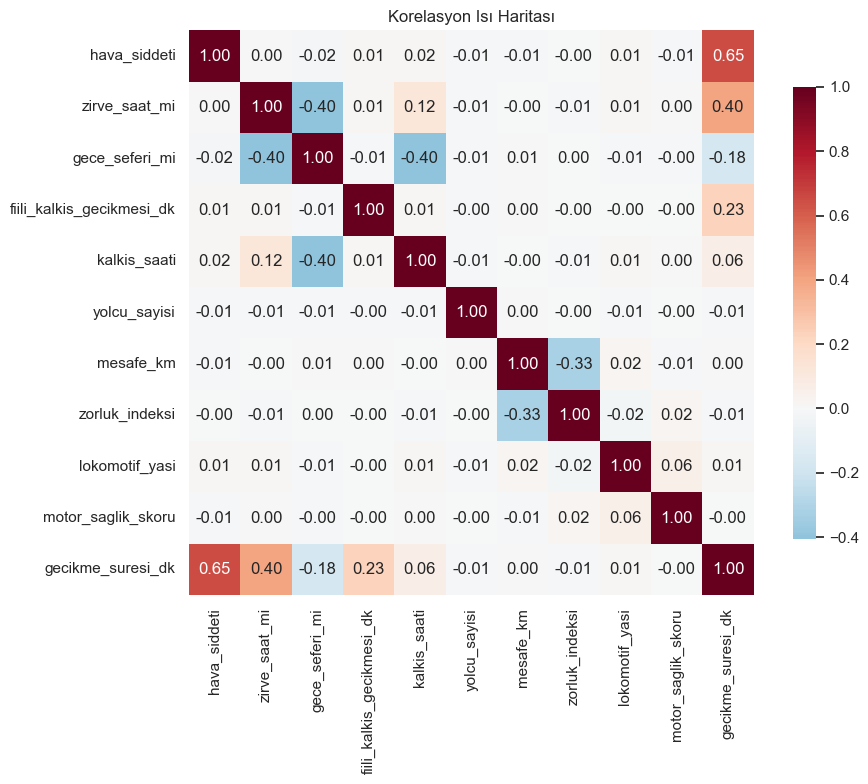

In [42]:
onemli = ["hava_siddeti","zirve_saat_mi","gece_seferi_mi","fiili_kalkis_gecikmesi_dk",
          "kalkis_saati","yolcu_sayisi","mesafe_km","zorluk_indeksi",
          "lokomotif_yasi","motor_saglik_skoru","gecikme_suresi_dk"]

plt.figure(figsize=(10,8))
sns.heatmap(df[onemli].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink":.8})
plt.title("Korelasyon Isı Haritası")
plt.tight_layout()
plt.show()

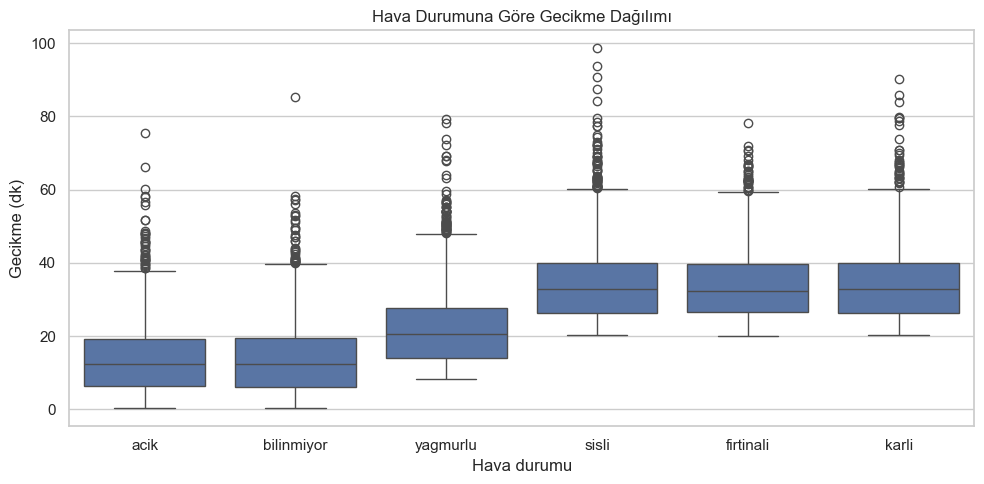

In [43]:
sira = ["acik","bilinmiyor","yagmurlu","sisli","firtinali","karli"]
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="hava_durumu", y="gecikme_suresi_dk", order=sira)
plt.title("Hava Durumuna Göre Gecikme Dağılımı")
plt.xlabel("Hava durumu"); plt.ylabel("Gecikme (dk)")
plt.tight_layout(); plt.show()

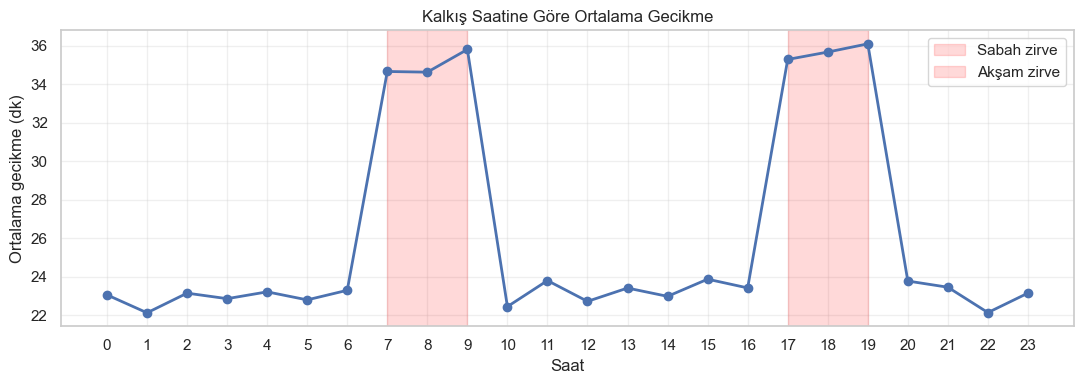

In [44]:
saatlik = df.groupby("kalkis_saati")["gecikme_suresi_dk"].mean()

plt.figure(figsize=(11,4))
plt.plot(saatlik.index, saatlik.values, marker="o", linewidth=2)
plt.axvspan(7, 9, alpha=.15, color="red", label="Sabah zirve")
plt.axvspan(17, 19, alpha=.15, color="red", label="Akşam zirve")
plt.xticks(range(24)); plt.grid(alpha=.3); plt.legend()
plt.title("Kalkış Saatine Göre Ortalama Gecikme")
plt.xlabel("Saat"); plt.ylabel("Ortalama gecikme (dk)")
plt.tight_layout(); plt.show()

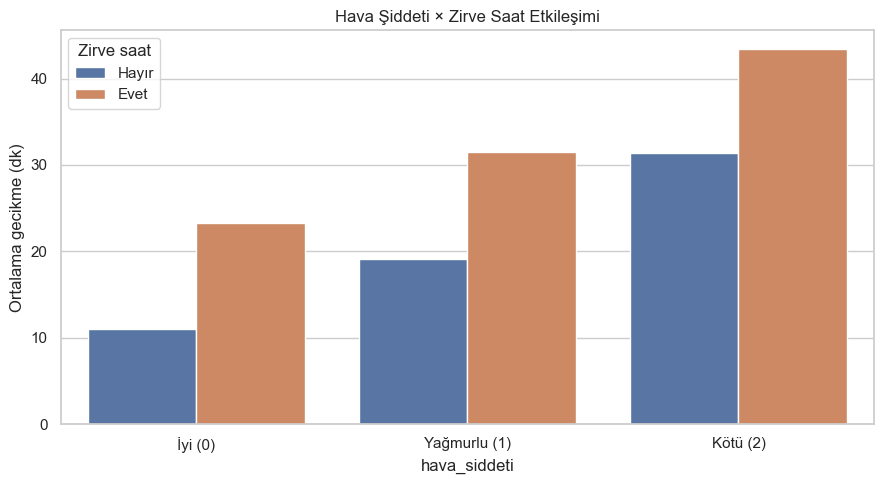

In [45]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x="hava_siddeti", y="gecikme_suresi_dk", hue="zirve_saat_mi",
            errorbar=None)
plt.xticks([0,1,2], ["İyi (0)","Yağmurlu (1)","Kötü (2)"])
plt.legend(title="Zirve saat", labels=["Hayır","Evet"])
plt.title("Hava Şiddeti × Zirve Saat Etkileşimi")
plt.ylabel("Ortalama gecikme (dk)")
plt.tight_layout(); plt.show()

### Faz 3 Bulguları

**Türetilen özellikler:** kalkis_saati, haftanin_gunu, ay, mevsim, hafta_sonu_mu,
zirve_saat_mi, gece_seferi_mi, hava_siddeti, planlanan_sure_dk, ortalama_hiz_kmh,
hiz_kullanim_orani, km_basina_viraj, km_basina_gecit, yillik_km, asinma_yas_orani

**Gecikmenin başlıca sürücüleri:**
| Özellik | r | Etki |
|---|---|---|
| hava_siddeti | 0.651 | Kötü hava ~+20 dk |
| zirve_saat_mi | 0.401 | Zirve saat ~+12 dk |
| fiili_kalkis_gecikmesi_dk | 0.233 | Kalkış gecikmesi varışa taşınıyor |
| gece_seferi_mi | -0.177 | Gece seferleri daha az gecikiyor |

**Öne çıkan gözlemler:**
- kalkis_saati'nin ham korelasyonu 0.062 idi; çift tepeli (W şeklinde) yapıyı
  korelasyon göremiyordu. zirve_saat_mi bayrağı bu sinyali 0.401'e çıkardı.
- Etkiler toplamsal: zirve saatin etkisi her hava koşulunda sabit ~12 dk.
  Gecikme ≈ 11 + (hava_siddeti × 10) + (zirve_saat × 12)
- Mevsim etkisiz (yayılım 0.7 dk) — hava durumu mevsimden bağımsız atanmış.
- Fiziksel oran özelliklerinin hiçbiri sinyal vermedi (|r| < 0.02).
- ortalama_hiz_kmh max 534 km/s çıktı; mesafe/süre verilerinde tutarsızlık var.


## 4. Modeling & Benchmark

In [46]:
disari = ["gecikme_suresi_dk", "planlanan_kalkis", "planlanan_varis",
          "tren_id", "hat_id", "hava_durumu"]

X = df.drop(columns=disari)
y = df["gecikme_suresi_dk"]

X = pd.get_dummies(X, drop_first=True)

print("X boyutu:", X.shape)
print("\nOne-hot sonrası eklenen sütunlar:")
print([c for c in X.columns if any(k in c for k in ["tipi_", "mevsim_"])])

X boyutu: (11853, 44)

One-hot sonrası eklenen sütunlar:
['tren_tipi_Banliyo', 'tren_tipi_Bolgesel', 'tren_tipi_YHT', 'tren_tipi_Yuk', 'hat_tipi_Elektrikli-Sinyalli', 'hat_tipi_Tek Hat', 'hat_tipi_Yüksek Hizli', 'mevsim_kis', 'mevsim_sonbahar', 'mevsim_yaz']


In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Eğitim: {X_train.shape[0]:,} satır")
print(f"Test  : {X_test.shape[0]:,} satır")

Eğitim: 9,482 satır
Test  : 2,371 satır


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sonuclar = []

def degerlendir(model, isim, hiperparam="Default"):
    model.fit(X_train, y_train)
    tahmin_tr = model.predict(X_train)
    tahmin_te = model.predict(X_test)

    kayit = {
        "Model": isim,
        "Hiperparametre": hiperparam,
        "Train MAE": mean_absolute_error(y_train, tahmin_tr),
        "Test MAE":  mean_absolute_error(y_test, tahmin_te),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, tahmin_te)),
        "Train R²":  r2_score(y_train, tahmin_tr),
        "Test R²":   r2_score(y_test, tahmin_te),
    }
    sonuclar.append(kayit)
    print(f"{isim:28s} Test MAE {kayit['Test MAE']:5.2f} | "
          f"RMSE {kayit['Test RMSE']:5.2f} | R² {kayit['Test R²']:.3f}")
    return model

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print(f"BASELINE (herkese medyan): MAE {baseline_mae:.2f}\n")

lr = degerlendir(LinearRegression(), "Linear Regression")
dt = degerlendir(DecisionTreeRegressor(random_state=42), "Decision Tree (ayarsız)")
rf = degerlendir(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                 "Random Forest", "n_estimators=100")

BASELINE (herkese medyan): MAE 10.47

Linear Regression            Test MAE  5.77 | RMSE  7.68 | R² 0.641
Decision Tree (ayarsız)      Test MAE  8.63 | RMSE 12.13 | R² 0.106
Random Forest                Test MAE  6.13 | RMSE  8.02 | R² 0.608


In [50]:
tablo = pd.DataFrame(sonuclar)
print(tablo[["Model","Train MAE","Test MAE","Train R²","Test R²"]].round(3).to_string(index=False))

                  Model  Train MAE  Test MAE  Train R²  Test R²
      Linear Regression      5.971     5.766     0.633    0.641
Decision Tree (ayarsız)      0.000     8.631     1.000    0.106
          Random Forest      2.352     6.127     0.945    0.608


In [51]:
print("max_depth taraması:\n")
for d in [3, 4, 5, 6, 8, 10, 15, None]:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    tr = r2_score(y_train, m.predict(X_train))
    te = r2_score(y_test,  m.predict(X_test))
    print(f"  max_depth={str(d):>4}  Train R² {tr:.3f}  Test R² {te:.3f}  fark {tr-te:+.3f}")

max_depth taraması:

  max_depth=   3  Train R² 0.602  Test R² 0.603  fark -0.001
  max_depth=   4  Train R² 0.629  Test R² 0.629  fark -0.000
  max_depth=   5  Train R² 0.642  Test R² 0.621  fark +0.021
  max_depth=   6  Train R² 0.655  Test R² 0.588  fark +0.067
  max_depth=   8  Train R² 0.695  Test R² 0.545  fark +0.150
  max_depth=  10  Train R² 0.747  Test R² 0.491  fark +0.256
  max_depth=  15  Train R² 0.884  Test R² 0.295  fark +0.589
  max_depth=None  Train R² 1.000  Test R² 0.106  fark +0.894


In [52]:
dt2 = degerlendir(DecisionTreeRegressor(max_depth=4, random_state=42),
                  "Decision Tree (ayarlı)", "max_depth=4")

Decision Tree (ayarlı)       Test MAE  5.88 | RMSE  7.81 | R² 0.629


In [53]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = degerlendir(
    HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1,
                                   max_depth=6, random_state=42),
    "HistGradientBoosting", "max_iter=200, lr=0.1, max_depth=6")

HistGradientBoosting         Test MAE  5.91 | RMSE  7.88 | R² 0.623


In [54]:
rf2 = degerlendir(
    RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=20,
                          random_state=42, n_jobs=-1),
    "Random Forest (ayarlı)", "n_estimators=200, max_depth=8, min_samples_leaf=20")

Random Forest (ayarlı)       Test MAE  5.79 | RMSE  7.70 | R² 0.639


In [55]:
katsayilar = (pd.Series(lr.coef_, index=X.columns)
                .sort_values(key=abs, ascending=False).head(10))
print("En büyük 10 katsayı:\n")
print(katsayilar.round(2))
print(f"\nSabit terim (intercept): {lr.intercept_:.2f}")

En büyük 10 katsayı:

zirve_saat_mi                   12.08
hava_siddeti                    10.31
km_basina_viraj                 -2.13
km_basina_gecit                  1.63
fiili_kalkis_gecikmesi_dk        0.74
hat_tipi_Tek Hat                 0.61
yolcu_sayisi_eksikti             0.52
hat_tipi_Elektrikli-Sinyalli    -0.31
tren_tipi_Banliyo                0.31
zorluk_indeksi                   0.23
dtype: float64

Sabit terim (intercept): 7.75


In [56]:
# Katsayı × standart sapma = gerçek etki büyüklüğü
etki = (pd.Series(lr.coef_, index=X.columns) * X.std()).sort_values(key=abs, ascending=False)
print("Gerçek etki büyüklüğü (katsayı × std):\n")
print(etki.head(10).round(2))

Gerçek etki büyüklüğü (katsayı × std):

hava_siddeti                 8.63
zirve_saat_mi                5.23
fiili_kalkis_gecikmesi_dk    2.98
km_basina_viraj             -0.40
hat_tipi_Tek Hat             0.30
ortalama_hiz_kmh             0.27
hemzemin_gecit_sayisi       -0.17
yolcu_sayisi_eksikti         0.14
asinma_yas_orani             0.13
tren_tipi_Banliyo            0.12
dtype: float64


In [57]:
tablo = pd.DataFrame(sonuclar)
tablo = tablo.sort_values("Test MAE")
print(tablo[["Model","Hiperparametre","Test MAE","Test RMSE","Test R²"]]
        .round(3).to_string(index=False))
print(f"\nBaseline MAE: {baseline_mae:.2f}")

                  Model                                     Hiperparametre  Test MAE  Test RMSE  Test R²
      Linear Regression                                            Default     5.766      7.682    0.641
 Random Forest (ayarlı) n_estimators=200, max_depth=8, min_samples_leaf=20     5.791      7.704    0.639
 Decision Tree (ayarlı)                                        max_depth=4     5.879      7.812    0.629
   HistGradientBoosting                  max_iter=200, lr=0.1, max_depth=6     5.912      7.878    0.623
          Random Forest                                   n_estimators=100     6.127      8.025    0.608
Decision Tree (ayarsız)                                            Default     8.631     12.126    0.106

Baseline MAE: 10.47


In [58]:
onem = (pd.Series(rf2.feature_importances_, index=X.columns)
          .sort_values(ascending=False).head(10))
print("Random Forest özellik önemleri:\n")
print((onem*100).round(1).astype(str) + " %")

Random Forest özellik önemleri:

hava_siddeti                 62.7 %
zirve_saat_mi                22.8 %
fiili_kalkis_gecikmesi_dk     7.8 %
ortam_sicakligi_c             0.5 %
bagaj_vagonu_yuk_kg           0.5 %
yolcu_sayisi                  0.4 %
ortalama_hiz_kmh              0.4 %
biletli_doluluk_orani_pct     0.3 %
ruzgar_hizi_kmh               0.3 %
motor_saglik_skoru            0.3 %
dtype: object


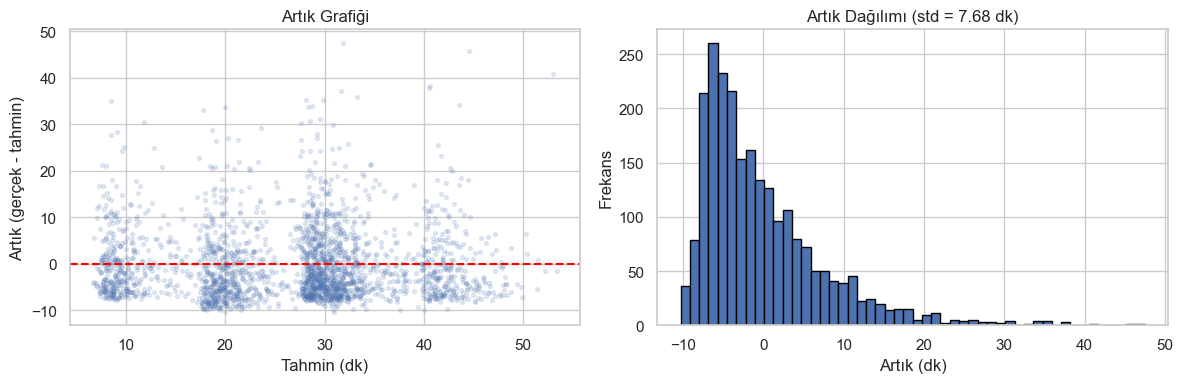


Hava şiddetine göre ortalama mutlak hata:
              mean  count
hava_siddeti             
0             5.61    592
1             6.04    587
2             5.71   1192


In [59]:
tahmin = lr.predict(X_test)
artik = y_test - tahmin

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(tahmin, artik, alpha=.15, s=8)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Tahmin (dk)"); plt.ylabel("Artık (gerçek - tahmin)")
plt.title("Artık Grafiği")

plt.subplot(1,2,2)
plt.hist(artik, bins=50, edgecolor="black")
plt.xlabel("Artık (dk)"); plt.ylabel("Frekans")
plt.title(f"Artık Dağılımı (std = {artik.std():.2f} dk)")

plt.tight_layout(); plt.show()

# Hangi koşullarda daha çok hata yapıyor?
test_df = X_test.copy()
test_df["mutlak_hata"] = abs(artik)
print("\nHava şiddetine göre ortalama mutlak hata:")
print(test_df.groupby("hava_siddeti")["mutlak_hata"].agg(["mean","count"]).round(2))

## 5. Conclusions

### Sonuçlar

**Model karşılaştırması** (baseline MAE 10.47 dk)

| Model | Hiperparametre | Test MAE | Test RMSE | Test R² |
|---|---|---|---|---|
| Linear Regression | Default | 5.77 | 7.68 | 0.641 |
| Random Forest (ayarlı) | n_estimators=200, max_depth=8, min_samples_leaf=20 | 5.79 | 7.70 | 0.639 |
| Decision Tree (ayarlı) | max_depth=4 | 5.88 | 7.81 | 0.629 |
| HistGradientBoosting | max_iter=200, lr=0.1, max_depth=6 | 5.91 | 7.88 | 0.623 |
| Decision Tree (ayarsız) | Default | 8.63 | 12.13 | 0.106 |

**En iyi model: Linear Regression.** Tüm modeller baseline'ı %45 iyileştirdi ve
5.8–5.9 MAE bandında yakınsadı.

**Neden lineer model kazandı:** EDA, etkilerin toplamsal olduğunu gösterdi
(zirve saatin etkisi her hava koşulunda sabit ~12 dk). Yakalanacak doğrusal
olmayan etkileşim olmadığı için ensemble modellerin avantajı yok; ağaçlar
sürekli değişkenleri basamaklara böldüğü için hafif hassasiyet kaybediyor.

**Sürücüler** (iki bağımsız yöntem aynı sonucu verdi):
| Özellik | Katsayı × std | RF önem |
|---|---|---|
| hava_siddeti | 8.63 | 62.7% |
| zirve_saat_mi | 5.23 | 22.8% |
| fiili_kalkis_gecikmesi_dk | 2.98 | 7.8% |

Üç özellik açıklanan varyansın %93'ünü taşıyor.

**Modelin tavanı:** R² 0.641, yani varyansın %36'sı açıklanamıyor. Artık analizi
bu kalıntının sistematik değil rastgele olduğunu gösterdi (hata tüm hava
koşullarında eşit: 5.6–6.0 dk). Artıkların sağa çarpık olması gecikmenin
doğasından kaynaklanıyor: alt sınır 0, üst sınır yok.

**Overfitting:** Ayarsız karar ağacı eğitim setini birebir ezberledi
(Train R² 1.000, Test R² 0.106). max_depth=4 ile test R² 0.629'a çıktı —
altı kat iyileşme.

## 6. Demo Model & Deployment

In [61]:
print(df.shape)
print([c for c in ["hava_siddeti", "zirve_saat_mi", "gece_seferi_mi",
                   "fiili_kalkis_gecikmesi_dk", "gecikme_suresi_dk"]
       if c not in df.columns])

(11853, 43)
[]


In [63]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Arayüzde kullanıcıdan alabileceğimiz / hesaplayabileceğimiz özellikler
DEMO_FEATURES = ["hava_siddeti", "zirve_saat_mi" , "fiili_kalkis_gecikmesi_dk"]

X_demo = df[DEMO_FEATURES]
y = df["gecikme_suresi_dk"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_demo, y, test_size=0.2, random_state=42
)

demo_model = LinearRegression()
demo_model.fit(X_tr, y_tr)

pred = demo_model.predict(X_te)
print("Demo MAE :", round(mean_absolute_error(y_te, pred), 2))
print("Demo R2  :", round(r2_score(y_te, pred), 3))
print("Sabit    :", round(demo_model.intercept_, 2))
for ad, kat in zip(DEMO_FEATURES, demo_model.coef_):
    print(f"  {ad:28s} {kat:7.2f}")

joblib.dump({"model": demo_model, "features": DEMO_FEATURES},
            "tcdd_demo_model.pkl")
print("\nModel kaydedildi -> tcdd_demo_model.pkl")

Demo MAE : 5.75
Demo R2  : 0.643
Sabit    : 7.42
  hava_siddeti                   10.31
  zirve_saat_mi                  12.13
  fiili_kalkis_gecikmesi_dk       0.74

Model kaydedildi -> tcdd_demo_model.pkl


In [64]:
%pip install gradio

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/30.8 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.8 MB 6.6 MB/s eta 0:00:05
   ---- ----------------------------------- 3.7/30.8 MB 11.5 MB/s eta 0:00:03
   -------- ------------------------------- 6.3/30.8 MB 12.1 MB/s eta 0:00:03
   ----------- ---------------------------- 8.9/30.8 MB 11.8 MB/s eta 0:00:02
   --------------- ------------------------ 11.8/30.8 MB 12.1 MB/s eta 0:00:02
   ------------------- -------------------- 14.7/30.8 MB 12.5 MB/s eta 0:00:02
   ----------------------- ---------------- 17.8/30.8 MB 12.6 MB/s eta 0:00:02
   -------------------------- ------------- 20.7/30.8 MB 12.8 MB/s eta 0:00:01
   ------------------------------ --------- 23.6/30.8 MB 13.0 MB/s eta 0:00:01
   --------------------------------- ------ 25.7/30.8 MB 13.0 MB/s eta 0:00:01
   ------------------------------------- -- 28.6/30.8 MB 12.8 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import gradio as gr
import joblib
import pandas as pd

bundle = joblib.load("tcdd_demo_model.pkl")
model = bundle["model"]
FEATURES = bundle["features"]

HAVA_SIDDETI = {
    "Açık": 0, "Bilinmiyor": 0,
    "Yağmurlu": 1,
    "Sisli": 2, "Fırtınalı": 2, "Karlı": 2,
}

MAE = 5.75

def tahmin_et(hava, saat, kalkis_gecikmesi):
    hava_siddeti = HAVA_SIDDETI[hava]
    zirve_saat_mi = int(7 <= saat <= 9 or 17 <= saat <= 19)

    X = pd.DataFrame(
        [[hava_siddeti, zirve_saat_mi, kalkis_gecikmesi]],
        columns=FEATURES
    )
    tahmin = model.predict(X)[0]

    return f"""
### Tahmini varış gecikmesi: **{tahmin:.1f} dakika**

Beklenen aralık: {max(0, tahmin - MAE):.1f} – {tahmin + MAE:.1f} dk

**Tahmin nasıl oluştu**

| Bileşen | Katkı |
|---|---|
| Taban gecikme | {model.intercept_:.1f} dk |
| Hava şiddeti ({hava}, seviye {hava_siddeti}) | {hava_siddeti * model.coef_[0]:+.1f} dk |
| Zirve saat ({'evet' if zirve_saat_mi else 'hayır'}) | {zirve_saat_mi * model.coef_[1]:+.1f} dk |
| Kalkış gecikmesi ({kalkis_gecikmesi:.0f} dk) | {kalkis_gecikmesi * model.coef_[2]:+.1f} dk |
"""

with gr.Blocks(title="TCDD Gecikme Tahmini") as demo:
    gr.Markdown("# TCDD Sefer Gecikme Tahmini")
    gr.Markdown("Intellica stajı — 11.853 gerçek sefer kaydıyla eğitilmiş model.")

    with gr.Row():
        with gr.Column():
            hava_input = gr.Dropdown(
                choices=list(HAVA_SIDDETI.keys()),
                value="Açık",
                label="Hava durumu"
            )
            saat_input = gr.Slider(
                minimum=0, maximum=23, step=1, value=8,
                label="Kalkış saati"
            )
            gecikme_input = gr.Number(
                value=0, label="Kalkışta oluşan gecikme (dk)"
            )
            btn = gr.Button("Tahmin Et", variant="primary")

        with gr.Column():
            cikti = gr.Markdown("Değerleri seçip **Tahmin Et**'e bas.")

    gr.Examples(
        examples=[
            ["Açık", 3, 0],
            ["Açık", 8, 0],
            ["Karlı", 8, 0],
            ["Karlı", 8, 15],
        ],
        inputs=[hava_input, saat_input, gecikme_input],
        label="Hazır senaryolar",
    )

    btn.click(
        fn=tahmin_et,
        inputs=[hava_input, saat_input, gecikme_input],
        outputs=cikti
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [5]:
demo.close()

Closing server running on port: 7860
